# Tidy Tuesday 2/20/2026

Nate Dailey and Hasham Hussain

**Dataset**: Edible Plants Database

In [9]:
import pandas

edible_plants = pandas.read_csv('https://raw.githubusercontent.com/rfordatascience/tidytuesday/main/data/2026/2026-02-03/edible_plants.csv')

In [23]:
edible_plants.head()

,taxonomic_name,common_name,cultivation,sunlight,water,preferred_ph_lower,preferred_ph_upper,nutrients,soil,season,temperature_class,temperature_germination,temperature_growing,days_germination,days_harvest,nutritional_info,energy,sensitivities,description,requirements
0,Pisum sativum,Pea,Legume,Full sun,Very High,6.0,7.5,Medium,Loamy,Annual,Half hardy,24,4-24,6,55-75,"A good source of vitamin K, manganese, and die...",80.0,Drought intolerant,"The pea is the small spherical seed, or the se...","Require a sunny, nutrient-rich, moisture-reten..."
1,Phaseolus coccineus,Beans (Runner),Legume,Full sun,Medium,6.0,6.8,Medium,Loamy and clay,Annual,Tender,26,16-30,7,65-85,"A good source of protein, thiamine, and ribofl...",27.0,Drought intolerant,Runner bean plants are more productive than gr...,"Beans are a tender, warm-weather crop. They ar..."
2,Phaseolus vulgari,Beans (French),Legume,Full sun,Medium,6.0,7.5,Medium,Any well-drained and fertile,Annual,Tender,26,16-30,7,40-55,"A good source of protein, thiamine, and ribofl...",27.0,Drought intolerant,"French beans are the unripe fruit, and protect...","Beans are a tender, warm-weather crop. They ar..."
3,Vicia faba,Beans (Broad),Legume,Full sun/partial shade/full shade,Very Low,6.0,7.0,Medium,Any well-drained and fertile,Annual,Hardy,10,8-15,7,85-115,"A good source of vitamin-B6 (pyridoxine), thia...",88.0,Drought intolerant,Broad beans - also known as the fava bean - ar...,Broad beans are a cool weather crop. They grow...
4,Brassica oleracea,Cabbage (Spring),Legume,Full sun,High,6.0,7.5,High,Sand/loam/clay,biennial,Hardy,26,7-30,4,55-85,"A very good source of manganese, dietary fibre...",25.0,Particularly vulnerable to pests. Do not grow ...,Cabbages are a leafy green or purple biennial ...,Cabbage is a cool-season crop best planted in ...


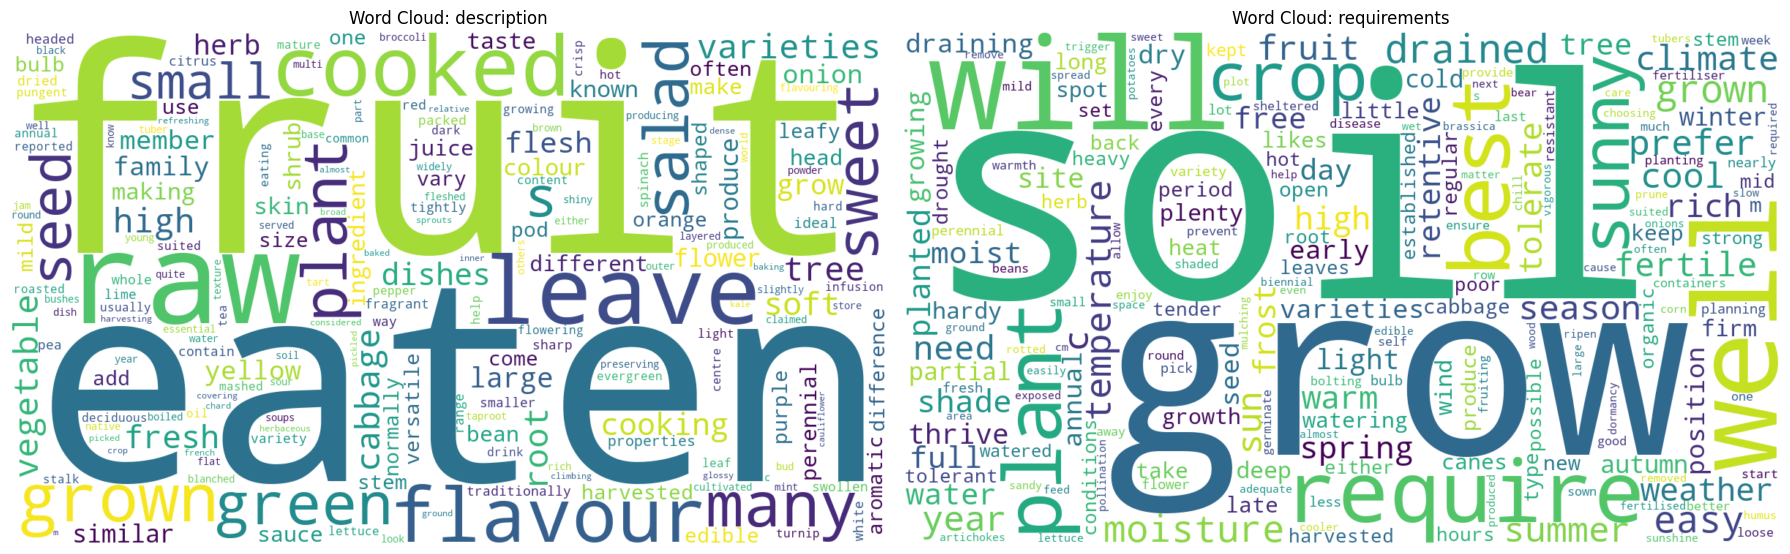

In [12]:
import re

import matplotlib.pyplot as plt
from wordcloud import WordCloud, STOPWORDS

def make_text(series):
    text = ' '.join(series.dropna().astype(str).tolist()).lower()
    # Basic cleanup: keep letters/spaces, collapse whitespace
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

for col in ['description', 'requirements']:
    if col not in edible_plants.columns:
        raise KeyError(f"Column '{col}' not found in edible_plants.")

stopwords = set(STOPWORDS)
stopwords.add('used')  # exclude this specific word

text_desc = make_text(edible_plants['description'])
text_req = make_text(edible_plants['requirements'])

wc_desc = WordCloud(
    width=1200,
    height=700,
    background_color='white',
    stopwords=stopwords,
    collocations=False,
).generate(text_desc)

wc_req = WordCloud(
    width=1200,
    height=700,
    background_color='white',
    stopwords=stopwords,
    collocations=False,
).generate(text_req)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
axes[0].imshow(wc_desc, interpolation='bilinear')
axes[0].axis('off')
axes[0].set_title('Word Cloud: description')

axes[1].imshow(wc_req, interpolation='bilinear')
axes[1].axis('off')
axes[1].set_title('Word Cloud: requirements')

plt.tight_layout()
plt.show()

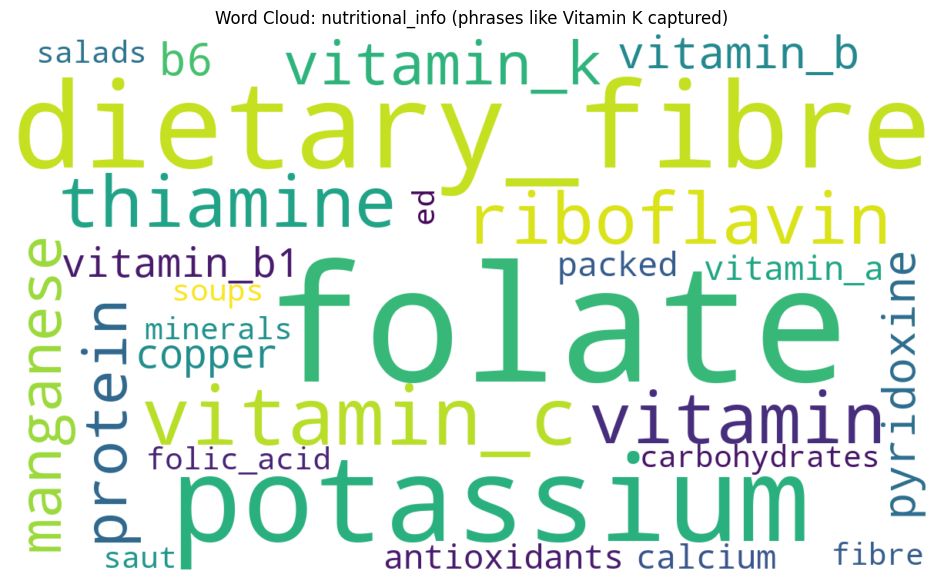

In [14]:
import re

import matplotlib.pyplot as plt
from wordcloud import WordCloud, STOPWORDS

# --- Nutrition word cloud (with phrase capture like "Vitamin K") ---
def _normalize_nutrition_text(value: str) -> str:
    t = str(value).lower()

    # Convert common nutrient phrases into single tokens so they appear as phrases in the cloud
    # Examples: "Vitamin K" -> "vitamin_k", "Vitamin B 12" -> "vitamin_b12"
    t = re.sub(r"\bvitamin\s+([a-z])\b", r"vitamin_\1", t)
    t = re.sub(r"\bvitamin\s+b\s*(\d{1,2})\b", r"vitamin_b\1", t)
    t = re.sub(r"\bfolic\s+acid\b", "folic_acid", t)
    t = re.sub(r"\bomega\s*[- ]?\s*(\d)\b", r"omega_\1", t)
    t = re.sub(r"\bdietary\s+fibre\b", "dietary_fibre", t)
    t = re.sub(r"\bdietary\s+fiber\b", "dietary_fiber", t)

    # Keep letters/digits/underscores/spaces; collapse whitespace
    t = re.sub(r"[^a-z0-9_\s]", " ", t)
    t = re.sub(r"\s+", " ", t).strip()
    return t

# Find the nutrition column (name varies by dataset)
nutrition_candidates = [c for c in edible_plants.columns if "nutri" in c.lower()]
if not nutrition_candidates:
    raise KeyError(
        "No nutrition-related column found (looked for 'nutri' in column names). "
        f"Available columns: {list(edible_plants.columns)}"
    )

nutrition_col = "nutritional_info" if "nutritional_info" in nutrition_candidates else nutrition_candidates[0]
nutrition_text = " ".join(
    _normalize_nutrition_text(x) for x in edible_plants[nutrition_col].dropna().astype(str).tolist()
).strip()

stopwords_nut = set(STOPWORDS)
stopwords_nut.update({"used", "source", "good", "especially", "high", "many", "rich"})

wc_nut = WordCloud(
    width=1200,
    height=700,
    background_color="white",
    stopwords=stopwords_nut,
    collocations=False,
).generate(nutrition_text)

plt.figure(figsize=(12, 7))
plt.imshow(wc_nut, interpolation="bilinear")
plt.axis("off")
plt.title(f"Word Cloud: {nutrition_col} (phrases like Vitamin K captured)")
plt.show()

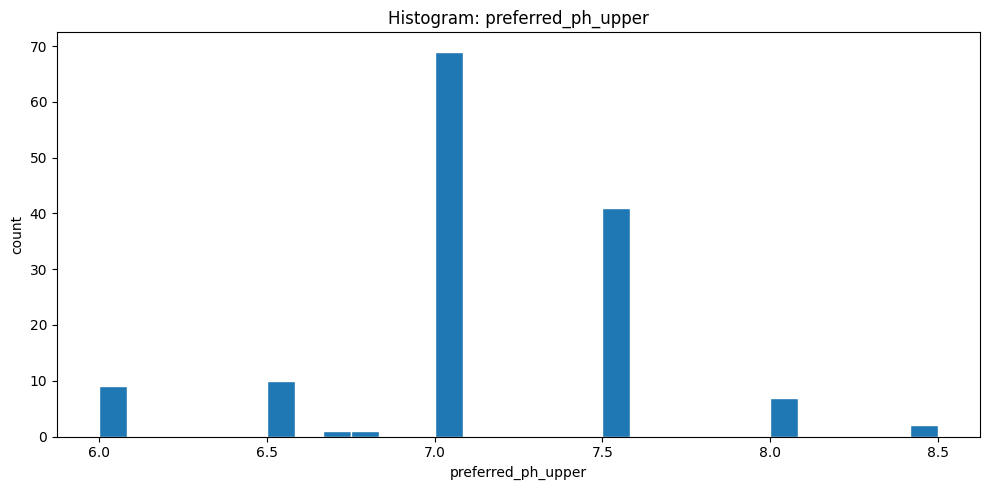

In [16]:
import matplotlib.pyplot as plt

col = 'preferred_ph_upper'
if col not in edible_plants.columns:
    raise KeyError(f"Column '{col}' not found. Available columns: {list(edible_plants.columns)}")

ph_upper = edible_plants[col]
ph_upper = ph_upper.astype(str).str.extract(r'([-+]?\d*\.?\d+)')[0].astype(float)

plt.figure(figsize=(10, 5))
plt.hist(ph_upper.dropna(), bins=30, edgecolor='white')
plt.title('Histogram: preferred_ph_upper')
plt.xlabel('preferred_ph_upper')
plt.ylabel('count')
plt.tight_layout()
plt.show()

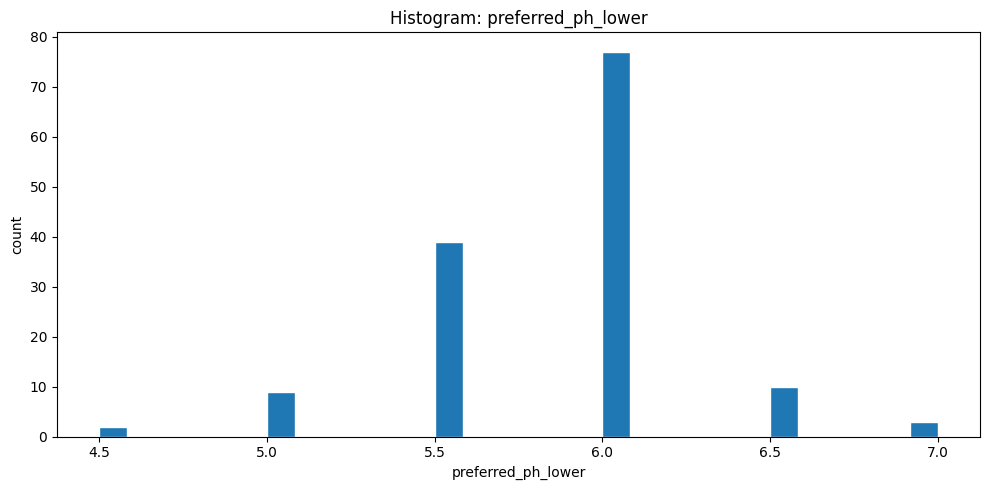

In [17]:
import matplotlib.pyplot as plt

col = 'preferred_ph_lower'
if col not in edible_plants.columns:
    raise KeyError(f"Column '{col}' not found. Available columns: {list(edible_plants.columns)}")

ph_lower = edible_plants[col]
ph_lower = ph_lower.astype(str).str.extract(r'([-+]?\d*\.?\d+)')[0].astype(float)

plt.figure(figsize=(10, 5))
plt.hist(ph_lower.dropna(), bins=30, edgecolor='white')
plt.title('Histogram: preferred_ph_lower')
plt.xlabel('preferred_ph_lower')
plt.ylabel('count')
plt.tight_layout()
plt.show()

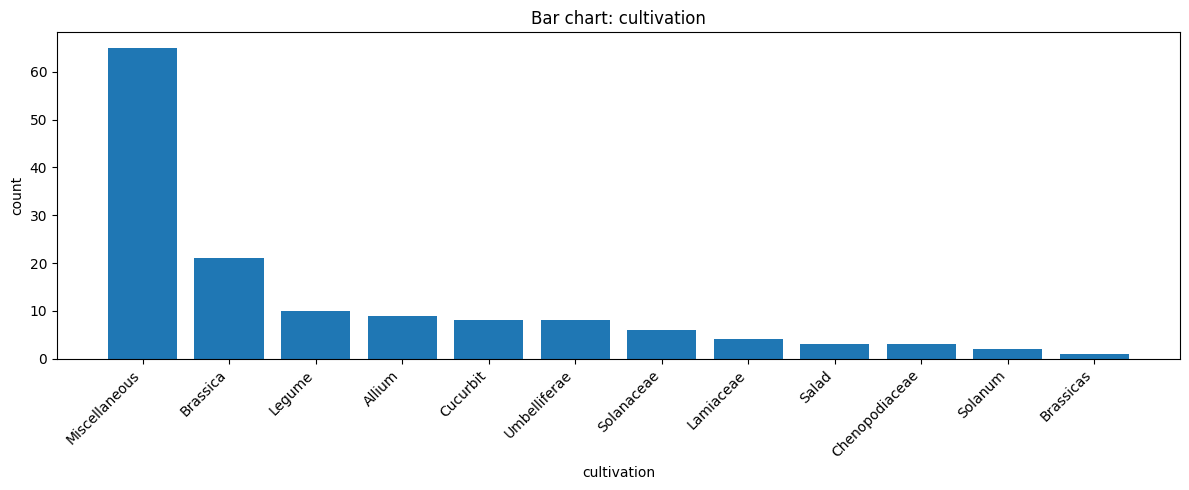

In [20]:
import matplotlib.pyplot as plt

col = 'cultivation'
if col not in edible_plants.columns:
    raise KeyError(f"Column '{col}' not found. Available columns: {list(edible_plants.columns)}")

counts = (
    edible_plants[col]
    .fillna('Missing')
    .astype(str)
    .replace({'': 'Missing'})
    .value_counts()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12, 5))
plt.bar(counts.index, counts.values)
plt.title('Bar chart: cultivation')
plt.xlabel('cultivation')
plt.ylabel('count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [25]:
import pandas as pd
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm

cat_col = 'cultivation'
y_col = 'preferred_ph_lower'
for col in [cat_col, y_col]:
    if col not in edible_plants.columns:
        raise KeyError(f"Column '{col}' not found. Available columns: {list(edible_plants.columns)}")

df = edible_plants[[cat_col, y_col]].copy()

# Clean outcome to numeric (handles strings like '6.5' or '6-7' by taking first number)
df[y_col] = (
    df[y_col]
    .astype(str)
    .str.extract(r'([-+]?\d*\.?\d+)')[0]
    .astype(float)
)

# Clean category and drop missing outcome
df[cat_col] = df[cat_col].fillna('Missing').astype(str).replace({'': 'Missing'})
df = df.dropna(subset=[y_col])

# Exclude Miscellaneous cultivation
df = df[df[cat_col].str.strip().str.lower() != 'miscellaneous'].copy()

# Keep groups with at least 2 observations (ANOVA needs within-group variance)
group_sizes = df.groupby(cat_col)[y_col].size().sort_values(ascending=False)
keep_groups = group_sizes[group_sizes >= 2].index
df = df[df[cat_col].isin(keep_groups)].copy()

print('Group sizes (kept for ANOVA):')
display(group_sizes.loc[keep_groups])
print('\nGroup means:')
display(df.groupby(cat_col)[y_col].mean().sort_values(ascending=False))

if df[cat_col].nunique() < 2:
    raise ValueError('Need at least 2 cultivation groups (with n>=2) to run ANOVA.')

model = ols(f"{y_col} ~ C({cat_col})", data=df).fit()
anova_table = anova_lm(model, typ=2)
print('\nOne-way ANOVA results:')
display(anova_table)

Group sizes (kept for ANOVA):


cultivation
Brassica          21
Legume            10
Allium             9
Cucurbit           8
Umbelliferae       8
Solanaceae         6
Lamiaceae          4
Chenopodiaceae     3
Salad              3
Solanum            2
Name: preferred_ph_lower, dtype: int64


Group means:


cultivation
Lamiaceae         6.125000
Allium            6.000000
Chenopodiaceae    6.000000
Legume            6.000000
Salad             6.000000
Brassica          5.976190
Cucurbit          5.812500
Solanaceae        5.666667
Umbelliferae      5.625000
Solanum           5.500000
Name: preferred_ph_lower, dtype: float64


One-way ANOVA results:


,sum_sq,df,F,PR(>F)
C(cultivation),1.887186,9.0,1.265717,0.272867
Residual,10.602679,64.0,NaN,NaN


Our results show that there is not a significant different in lower pH by cultivation type (fail to reject the null hypothesis).